## Using biogeochemical Argo Data

### Biogeochemical Argo Floats

Biogeochemical Argo floats are floats equiped with sensors that measure biogeochemical variables. In oceanography, biogeochemical variables are fundamental for topics such as carbon uptake and the biological carbon pump, ocean acidification, oxygen minimum zones (OMZs), phytoplankton communities, respiration, and other living resources, among others. This information can be expanded with [Biogeochemical Argo](https://biogeochemical-argo.org/index.php) The biogeochemical Argo floats measure the Esential Ocean Variables (EOVs): oxygen concentration, chlorophyll-a concentration, nitrate concentration, pH, backscatter (suspended particles), and irradiance. More information on the EOVs can be found at [GOOS: Essential Ocean Variables](https://goosocean.org/what-we-do/framework/essential-ocean-variables/). Floats have usually 5-6 of these sensors.

<img src="https://github.com/euroargodev/argoonlineschool/raw/master/images/EOVs.png" width="650"/>


IMAGEN TABLA EOVs.


The BGC Argo program started in 2016 and aims to deploy 1000 measuring floats in the ocean. It is the largest source of BGC data in the ocean interior. Some of the applications of the BGC Argo program include monitoring the state of plankton in the ocean using chlorophyll, studying fish species distribution, observing acidification processes, investigating Oxygen Minimum Zones (OMZs), assessing carbon uptake, and contributing to more accurate model predictions and ocean data products.

### Data files organized by float and file access

The biogeochemical floats data can be accesed through the same channels as the core floats data. We will access through the *Argo data by Float* to use the biogeochemical floats.

The file organization is similar to what is shown in [Lesson 3.2 - Accesing Argo data by float](https://euroargodev.github.io/argoonlineschool/Lessons/L03_UsingArgoData/Chapter32_ArgoDatabyFloat_Intro.html). The *dac* folder contains 11 folders corresponding to each of the DACs. In the particular DAC folders, there is a folder for each of the float processed by the DAC indicated by the *WMO* number.

If the float is a biogeochemical float, inside the float folder we can find the following files:
- 6901773_meta.nc
- 6901773_prof.nc
- 6901773_Rtraj.nc
- 6901773_Sprof.nc
- 6901773_tech.nc
- profiles/

The files *meta*, *prof*, *Rtraj* and *tech* are common with the core Argo data. The file *6901773_Sprof.nc* contains the same core variables and the added biogeochemical variables in one single file, corresponding to the synthetic profiles. Inside the *Profiles* folder, are all the corresponding profiles of this float.

- BD6901773_001.nc
- D6901773_001.nc
- SD6901773_001.nc

<img src="https://github.com/euroargodev/argoonlineschool/raw/master/images/DataFolder.png" width="650"/>

The files are named `<D/BD/S><FloatWmoID>_<XXX>.nc`, with the initial letters indicating the type of profile, the float ID, and *XXX* as the cycle number. The file *D6901773_001.nc* belongs to core Argo, and is the Delayed-Mode profile, indicated by the initial *D*. The file *BD6901773_001.nc* contains the b-profile for the core and biogeochemical variables, and the file *SD6901773_001.nc* the synthetic profile for the core and biogeochemical variables. Synthetic profiles have the standarized relevant biogeochemical variables, already adjusted.

The Biogeochemical Argo program also offers an [interactive map](https://maps.biogeochemical-argo.com/bgcargo/) that displays all the active and inactive biogeochemical floats and gives access to their data.

### Biogeochemical data

First, let's import the necessary libraries for this notebook.

In [19]:
import numpy as np
import pandas as pd

import xarray as xr

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy

Now, we read the previolusly downloaded data from the float *6901773*.

In [20]:

file_path = "/home/ihg/ArgoOnlineSchool/BGCfloat/ejemplo_bgc_float/"

ds = xr.open_dataset(file_path + 'datos_downloadftp/6901773/6901773_Sprof.nc')

**Variables**

The biogeochemical variables in this float are shown as follows, with the variable name, the long name, and the units. The pH variable was not measured in this float. For more information on this subject, go to the [Argo documentation](https://www.argodatamgt.org/Documentation).

In [21]:
print(
    f"The biogeochemical variables are:\n"
    f" DOXY {ds.DOXY.long_name} ({ds.DOXY.units})\n"
    f" CHLA {ds.CHLA.long_name} ({ds.CHLA.units})\n"
    f" CHLA_FLUORESCENCE {ds.CHLA_FLUORESCENCE.long_name} ({ds.CHLA_FLUORESCENCE.units})\n"
    f" NITRATE {ds.NITRATE.long_name} ({ds.NITRATE.units})\n"
    f" BBP700 {ds.BBP700.long_name} ({ds.BBP700.units})\n"
    f" CDOM {ds.CDOM.long_name} ({ds.CDOM.units})\n"
    f" DOWN_IRRADIANCE380 {ds.DOWN_IRRADIANCE380.long_name} ({ds.DOWN_IRRADIANCE380.units})\n"
    f" DOWN_IRRADIANCE412 {ds.DOWN_IRRADIANCE412.long_name} ({ds.DOWN_IRRADIANCE412.units})\n"
    f" DOWN_IRRADIANCE490 {ds.DOWN_IRRADIANCE490.long_name} ({ds.DOWN_IRRADIANCE490.units})\n"
    f" DOWNWELLING_PAR {ds.DOWNWELLING_PAR.long_name} ({ds.DOWNWELLING_PAR.units})"
)


The biogeochemical variables are:
 DOXY Dissolved oxygen (micromole/kg)
 CHLA Chlorophyll-A (mg/m3)
 CHLA_FLUORESCENCE Chlorophyll fluorescence with factory calibration (ru)
 NITRATE Nitrate (micromole/kg)
 BBP700 Particle backscattering at 700 nanometers (m-1)
 CDOM Concentration of coloured dissolved organic matter in sea water (ppb)
 DOWN_IRRADIANCE380 Downwelling irradiance at 380 nanometers (W/m^2/nm)
 DOWN_IRRADIANCE412 Downwelling irradiance at 412 nanometers (W/m^2/nm)
 DOWN_IRRADIANCE490 Downwelling irradiance at 490 nanometers (W/m^2/nm)
 DOWNWELLING_PAR Downwelling photosynthetic available radiation (microMoleQuanta/m^2/sec)


**Data structure**

Printing the structure of the data, we can observe that the float performed 295 profiles and 1342 vertical levels, with 13 parameters (3 core + 10 biogeochemical, shown in the previous cell). 

In [22]:
print(dict(ds.sizes))

{'N_PROF': 295, 'N_PARAM': 13, 'N_CALIB': 1, 'N_LEVELS': 1342}


We can also look at the data mode (Real-Time (R), Real-Time with adjusted variables (A), Delayed (D)) of the parameters. This table shows the data mode corresponding to each parameter.

In [23]:
params = ds.PARAMETER[0, 0, :].values
modes  = ds.PARAMETER_DATA_MODE[0, :].values

for i in range(len(params)):
    p = params[i].decode().strip()
    m = modes[i].decode().strip()
    print(f"{p:25s} {m}")

PRES                      D
TEMP                      D
PSAL                      D
DOXY                      D
DOWN_IRRADIANCE380        R
DOWN_IRRADIANCE412        R
DOWN_IRRADIANCE490        R
DOWNWELLING_PAR           R
CHLA                      D
CHLA_FLUORESCENCE         R
BBP700                    A
CDOM                      R
NITRATE                   D


**Quality control**

Raw BGC-Argo data is tipically not suited for scientific use. The user manual recommends using the parameters adjusted, with mode “A” and quality flag  “1”. The quality control flags are assigned with the same values as core Argo, that were shown previously in [Lesson 3.4 - Real Time data](https://euroargodev.github.io/argoonlineschool/Lessons/L03_UsingArgoData/Chapter34b_RTData.html). Like in the core Argo data, the adjusted parameters have the following variables.

- `<PARAM>`: parameter without adjusting
- `<PARAM>_QC`: quality control flag
- `PROFILE_<PARAM>_QC`: quality control flag of the profile
- `<PARAM>_ADJUSTED`: adjusted parameter
- `<PARAM>_ADJUSTED_QC`: quality control flag of the adjusted parameter
- `<PARAM>_ADJUSTED_ERROR`: error of the adjusted parameter


### Float trajectory

Now, let's plot the float's position using *cartopy*.

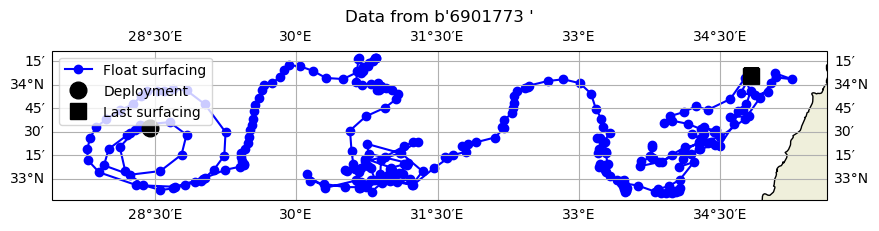

In [24]:

lon=ds.LONGITUDE[~np.isnan(ds.LONGITUDE) & ~np.isnan(ds.LATITUDE)]
lat=ds.LATITUDE[~np.isnan(ds.LONGITUDE) & ~np.isnan(ds.LATITUDE)]

fig,ax = plt.subplots(figsize=(10,10),subplot_kw={'projection': ccrs.PlateCarree()})
ax.plot(lon,lat,'-bo',label='Float surfacing')
ax.plot(lon[0],lat[0],'ok',markersize=12,label='Deployment')
ax.plot(lon[-1],lat[-1],'sk',markersize=12,label='Last surfacing')

ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), edgecolor='black')

ax.set_title(f"Data from {ds.PLATFORM_NUMBER.values[0]}")
ax.legend()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False);

### Visualization of the biogeochemical data

For the vertical sections we will interpolate the data in depth first, using the same method as [Lesson 3.2 - Accesing Argo data by float - Accesing all profiles at once](https://euroargodev.github.io/argoonlineschool/Lessons/L03_UsingArgoData/Chapter32c_ArgoDatabyFloat_Prof.html). Biogeochemical proccessed data has a higher amount of Not A Number (NaN) data points, so we need to take the NaN values into account to obtain a good interpolation.

First, we will create the variables that will be interpolated.

In [25]:
prei=np.arange(5,1030,5)

juld=ds.JULD.values
pres=ds.PRES_ADJUSTED.values

doxy=ds.DOXY.values
doxya=ds.DOXY_ADJUSTED.values
chla = ds.CHLA_ADJUSTED.values
nitr = ds.NITRATE.values
nitra = ds.NITRATE_ADJUSTED.values
bbp = ds.BBP700_ADJUSTED.values
cdom = ds.CDOM_ADJUSTED.values
downpar = ds.DOWNWELLING_PAR_ADJUSTED.values
irr380 = ds.DOWN_IRRADIANCE380_ADJUSTED.values
irr412 = ds.DOWN_IRRADIANCE412_ADJUSTED.values
irr490 = ds.DOWN_IRRADIANCE490_ADJUSTED.values

The interpolated vectors must be created previously and filled with NaN values.

In [26]:
doxyi= np.zeros((juld.shape[0],prei.shape[0]))
doxyi.fill(np.nan)

doxyai= np.zeros((juld.shape[0],prei.shape[0]))
doxyai.fill(np.nan)

chlai= np.zeros((juld.shape[0],prei.shape[0]))
chlai.fill(np.nan)

nitri= np.zeros((juld.shape[0],prei.shape[0]))
nitri.fill(np.nan)

nitrai = np.zeros((juld.shape[0],prei.shape[0]))
nitrai.fill(np.nan)

bbpi= np.zeros((juld.shape[0],prei.shape[0]))
bbpi.fill(np.nan)

cdomi= np.zeros((juld.shape[0],prei.shape[0]))
cdomi.fill(np.nan)

downpari= np.zeros((juld.shape[0],prei.shape[0]))
downpari.fill(np.nan)

irr380i= np.zeros((juld.shape[0],prei.shape[0]))
irr380i.fill(np.nan)

irr412i= np.zeros((juld.shape[0],prei.shape[0]))
irr412i.fill(np.nan)

irr490i= np.zeros((juld.shape[0],prei.shape[0]))
irr490i.fill(np.nan)

For the interpolation, this code will not interpolate if the number of NaNs is too high and will create false data or propagate.

In [27]:
vars = [doxy, doxya, chla, nitr, bbp, cdom, downpar, irr380, irr412, irr490]
outs   = [doxyi, doxyai, chlai, nitri, bbpi, cdomi, downpari, irr380i, irr412i, irr490i]

# Interpolation loop
for var, var_i in zip(vars, outs):
    for ip in range(pres.shape[0]):
        # Mask to filter the valid profiles
        mask = ~np.isnan(pres[ip, :]) & ~np.isnan(var[ip, :])
        
        if np.sum(mask) < 2:
            continue
        
        pres_valid = pres[ip, mask]
        var_valid  = var[ip, mask]
        
        order = np.argsort(pres_valid)
        
        # Interpolation
        var_i[ip, :] = np.interp(prei, pres_valid[order], var_valid[order])

**Oxygen, nitrate and chlorophyll figures**

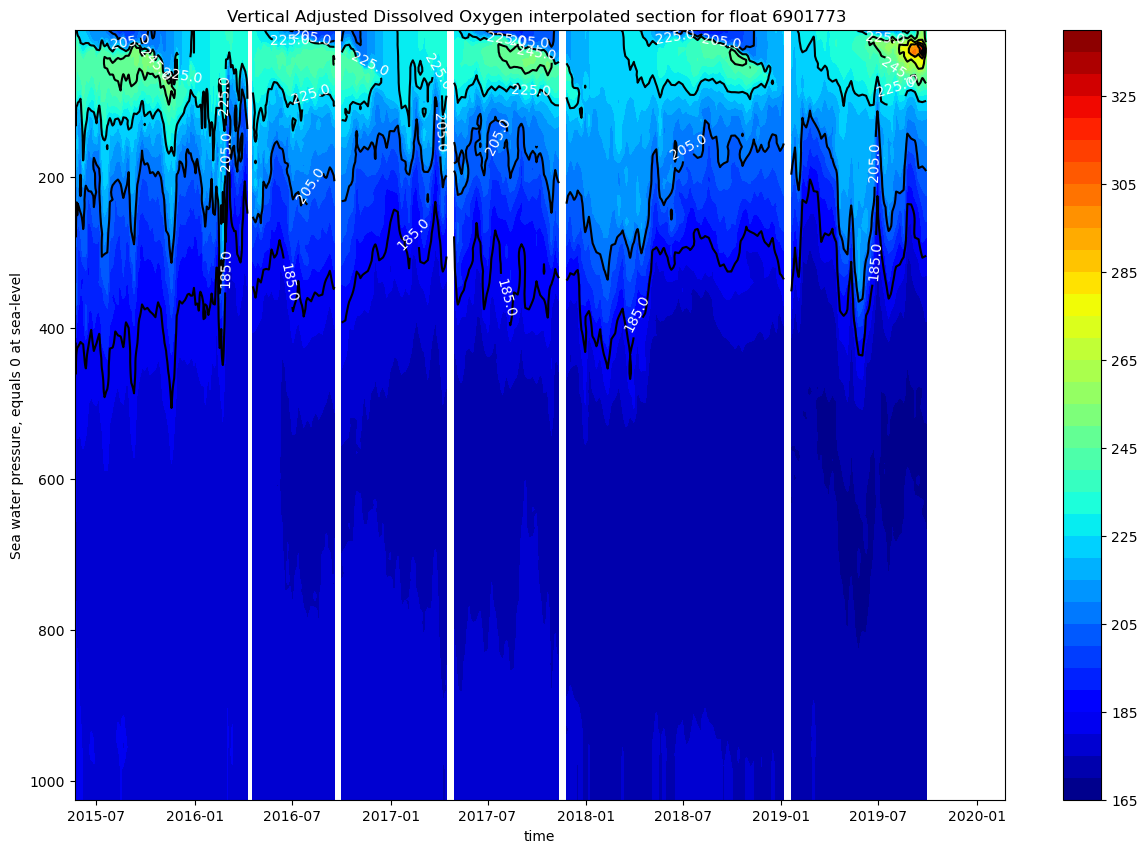

In [28]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,doxyai.transpose(),40, cmap = 'jet') #, vmin = 140, vmax = 260)
cs2=ax.contour(juld,prei,doxyai.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)

ax.set_title(f"Vertical Adjusted Dissolved Oxygen interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

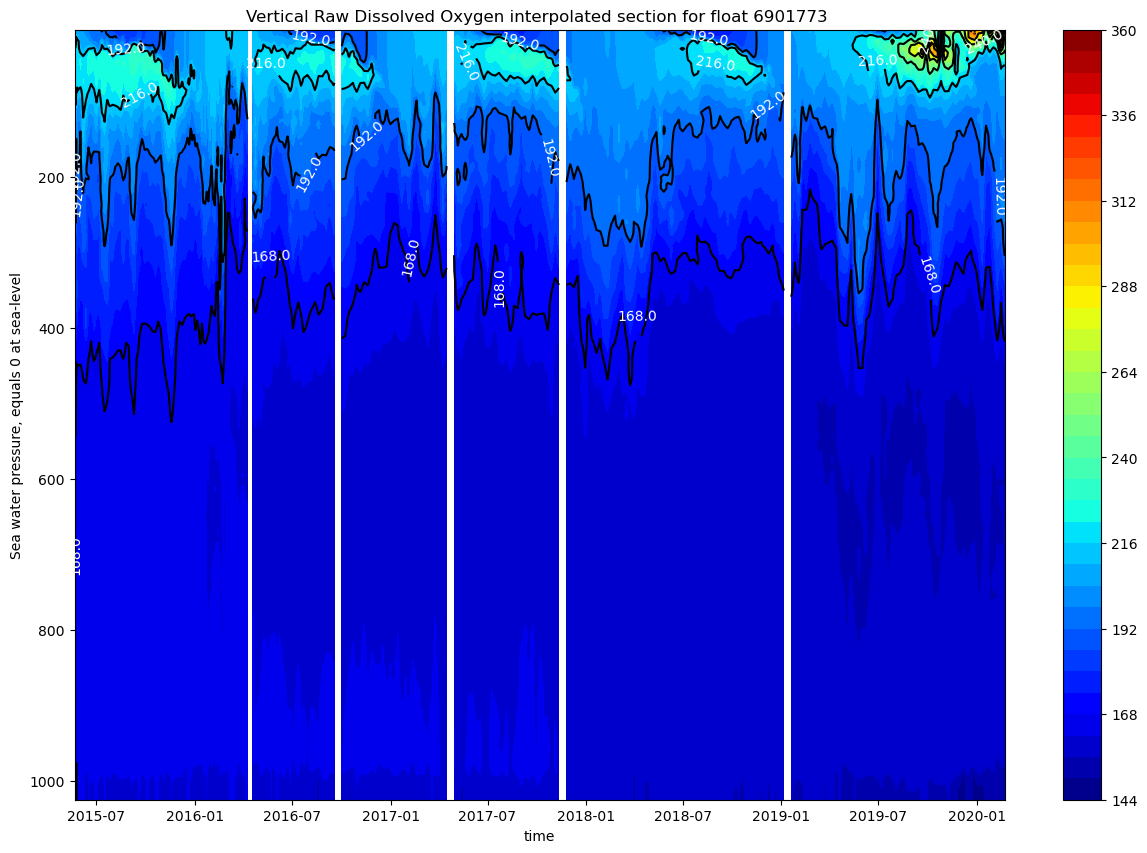

In [29]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,doxyi.transpose(),40, cmap = 'jet') #, vmin = 140, vmax = 260)
cs2=ax.contour(juld,prei,doxyi.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)

ax.set_title(f"Vertical Raw Dissolved Oxygen interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

The vertical oxygen profile shows strong seasonal stratification with oxygen-rich surface waters up to 100m (>200 μmol/kg), a prominent oxygen minimum zone at 200-400m depth (~165-185 μmol/kg), and relatively stable deep-water oxygen levels (~185-195 μmol/kg) from 2015-2020. There is also a strong seasonal cycle in the upper 200m.

DIFERENCIAS ENTRE AJUSTADO Y NO

If we watch this data with a different plot style (scatter), without the interpolation, we can observe that the columns with no data disappear. When the interpolation is done, the profiles that have a high number of NaN (Not a Number) are discarded and left blank.


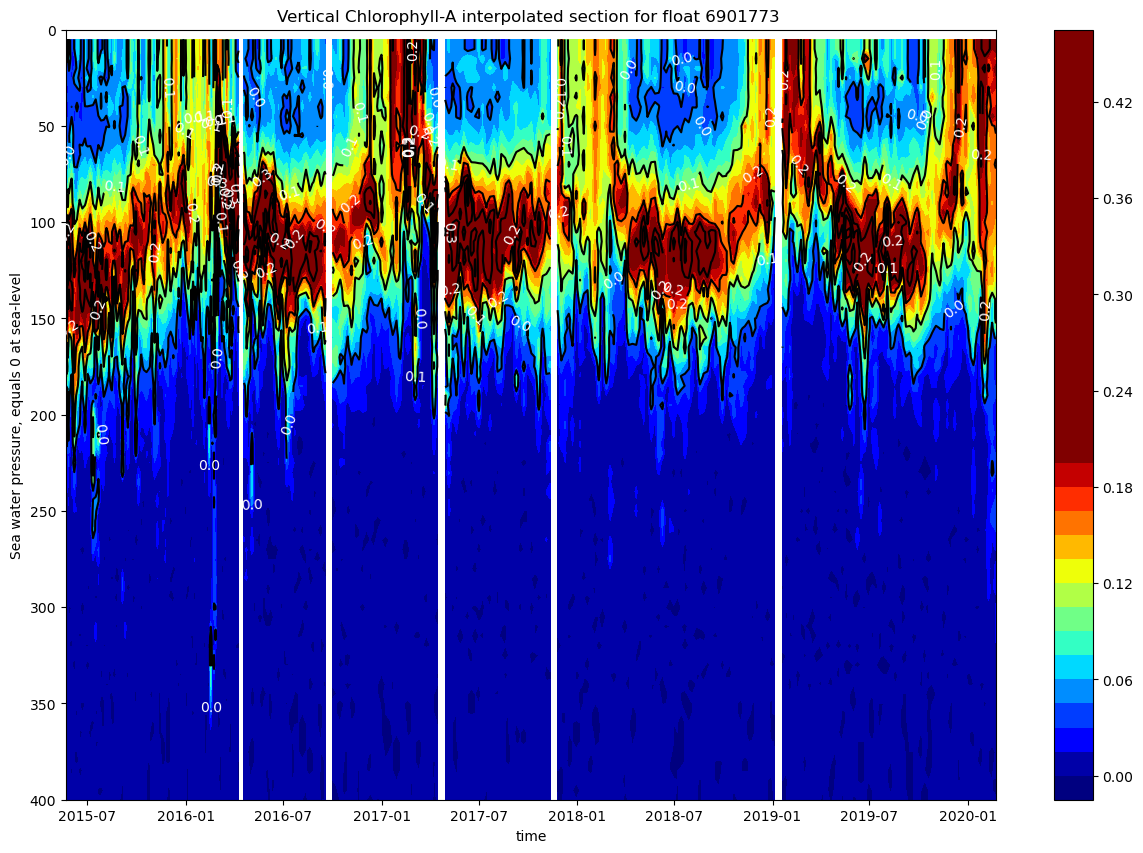

In [30]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,chlai.transpose(),40, cmap = 'jet', vmin = 0, vmax = 0.2)
cs2=ax.contour(juld,prei,chlai.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)
ax.set_ylim(400, 0)

ax.set_title(f"Vertical Chlorophyll-A interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

The chlorophyll is concentrated in the upper 200m with strong seasonal spring blooms (0.2-0.42 mg/m³) in late winter/spring, a persistent deep chlorophyll maximum (DCM) at 50-150m depth, and near-zero values below 200m, characteristic of the nutrient-limited Mediterranean Sea.



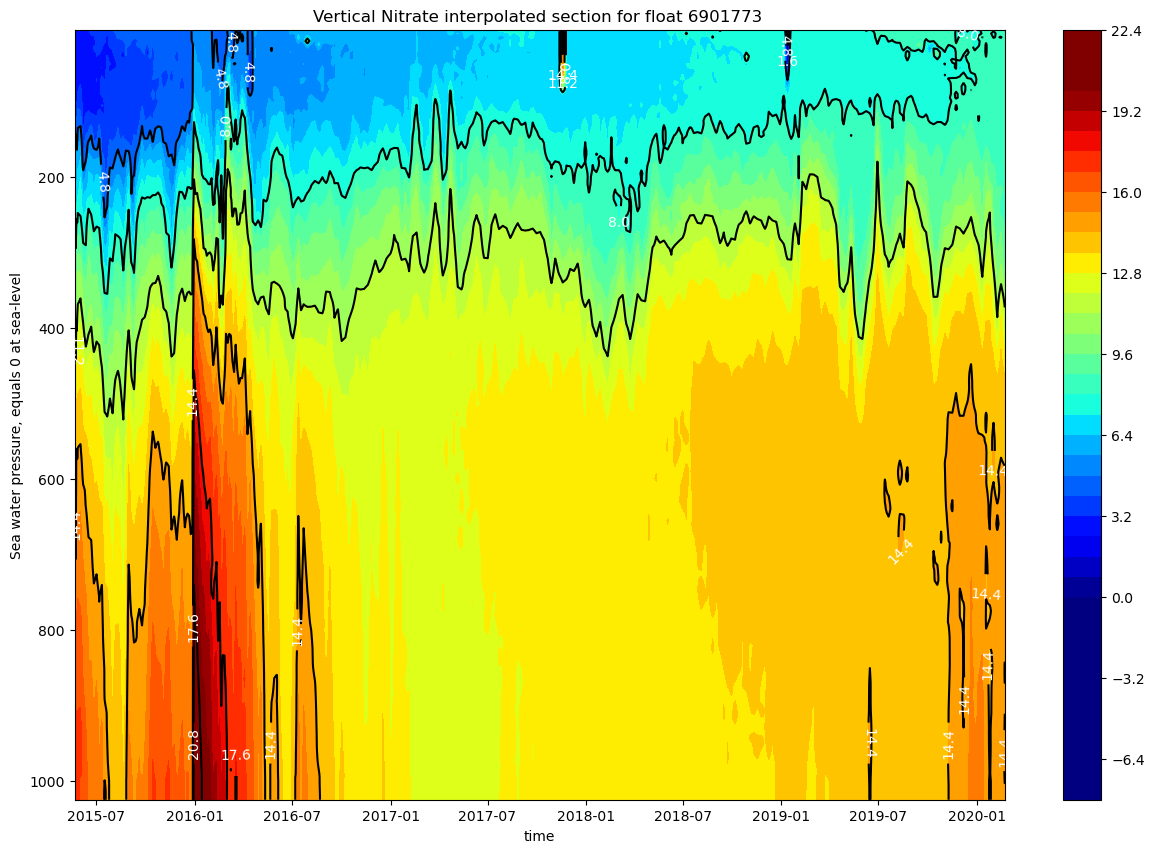

In [31]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,nitri.transpose(),40, cmap = 'jet', vmin = 0, vmax = 20)
cs2=ax.contour(juld,prei,nitri.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)

ax.set_title(f"Vertical Nitrate interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

The nitrate concentration is low on the upper layer (up to 200m), and increases with depth, forming a permanent nutricline. The upper 300m show a strong seasonal variability.

EXPLICAR EN DETALLE: NITRATO POR DESCOMPOSICIÓN.

**Suspended particles**

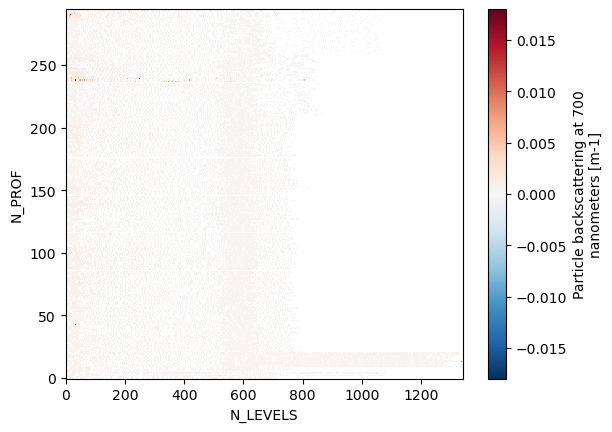

In [32]:
ds.BBP700_ADJUSTED.plot()

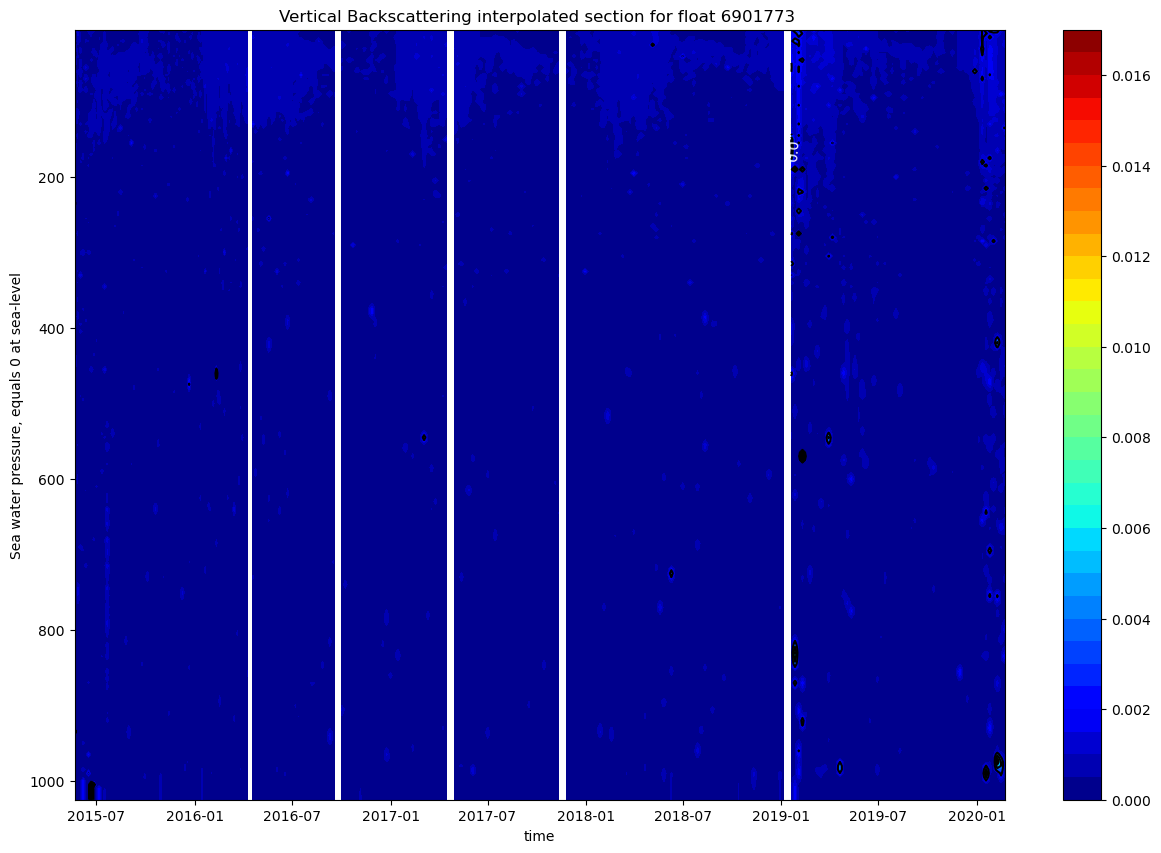

In [37]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,bbpi.transpose(),40, cmap = 'jet')#, vmin = 0.0002, vmax = 0.001)
cs2=ax.contour(juld,prei,bbpi.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)

ax.set_title(f"Vertical Backscattering interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

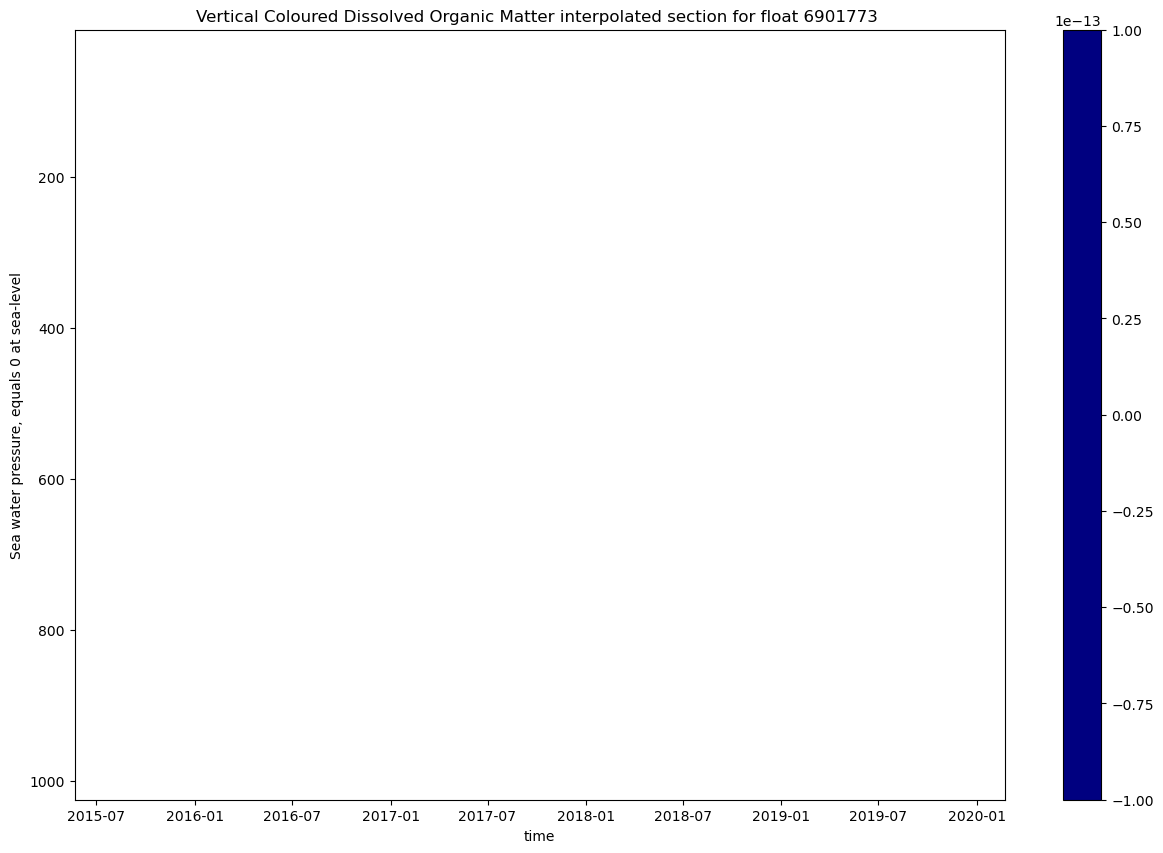

In [34]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,cdomi.transpose(),40, cmap = 'jet', vmin = 0, vmax = 2.5)
cs2=ax.contour(juld,prei,cdomi.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)

ax.set_title(f"Vertical Coloured Dissolved Organic Matter interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

The backscattering shows a high concentration of suspended particles in the upper 150m, indicating phytoplankton mass and detritus, and possible dust episodic inputs. In the deeper layers there is a lower backscattering value, meaning a particle attenuation, due to sinking, remineralization, and aggregation. There are some episodic high backscattering events, some penetrating deeper.

The CDOM results show a higher value below 200-300m, due to biological consumption and photobleaching on the surface. This is typical for oligotrophic basins. Both parameters show a clear seasonal cycle in the upper ocean, althoug it is stronger in the backscattering result.

Deberían dar esto (lo que me salia en el scatter)

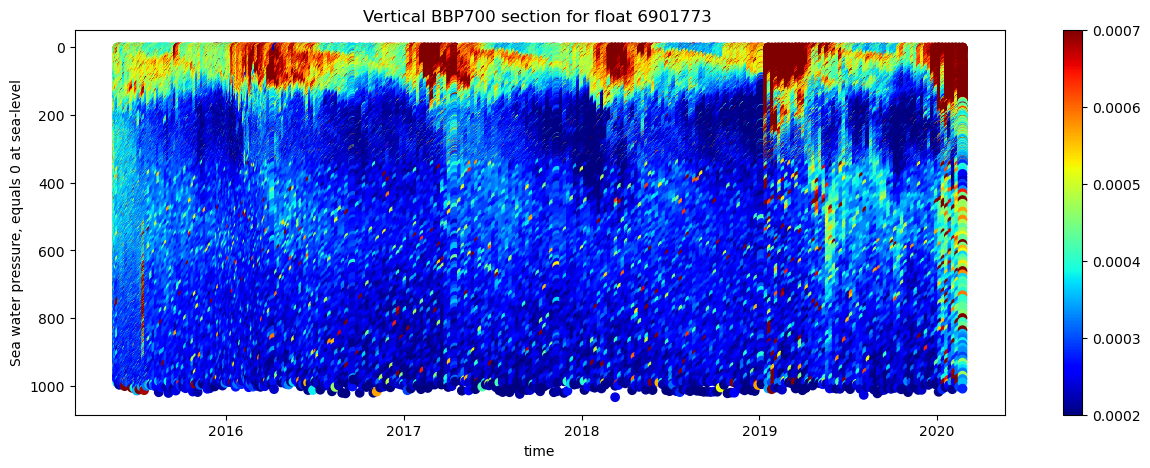
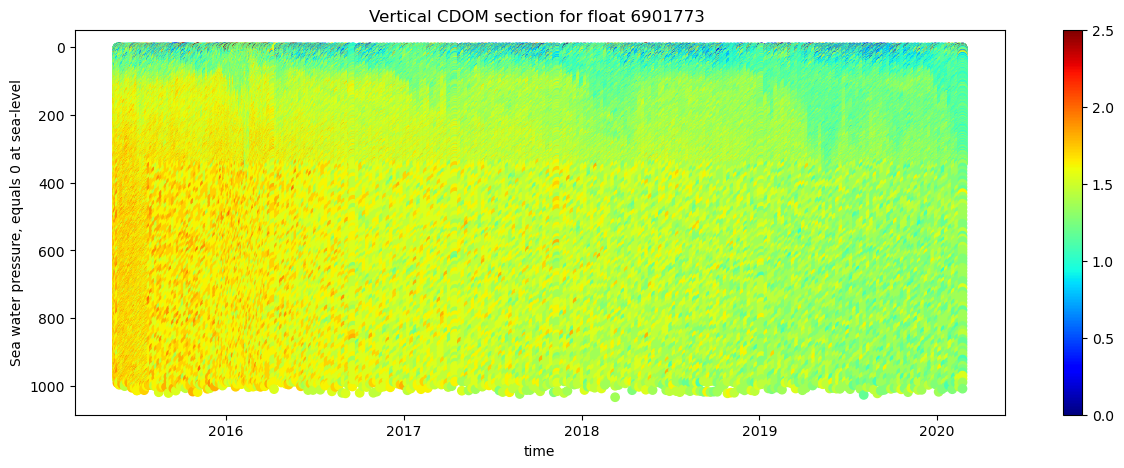


**Irradiance**

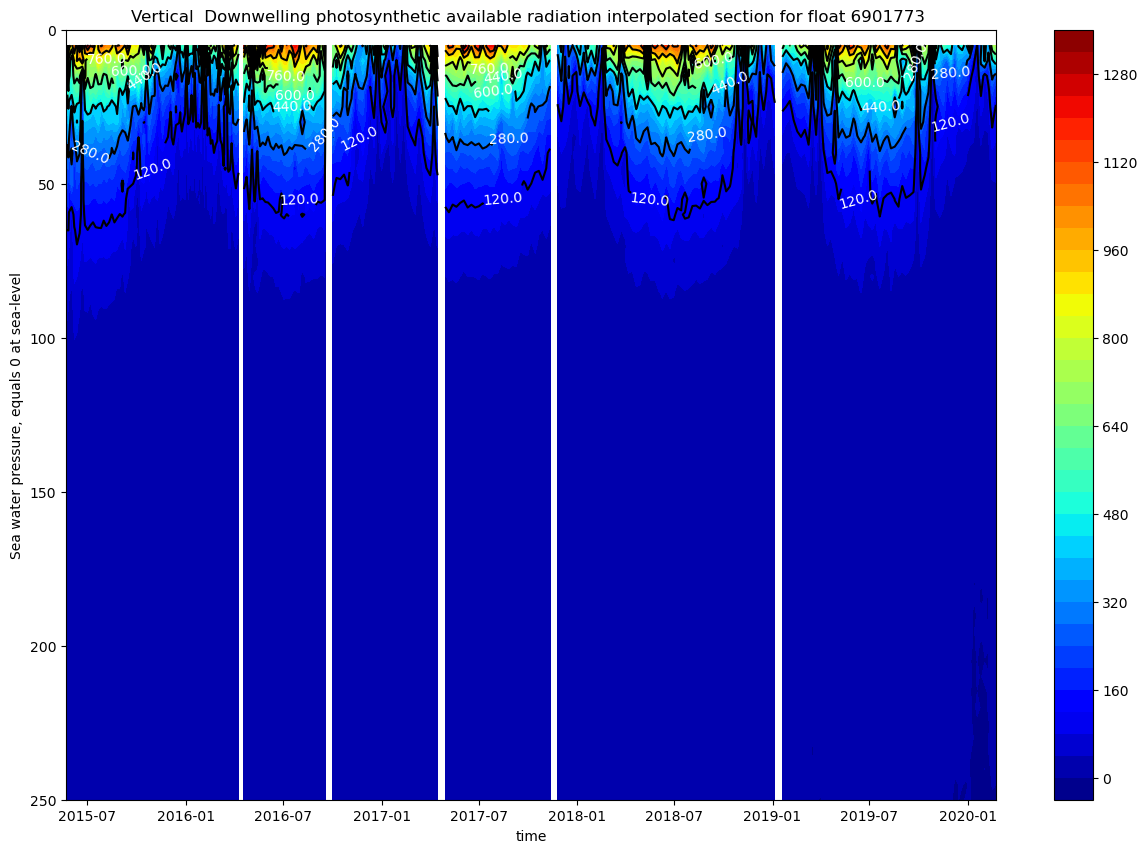

In [35]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,downpari.transpose(),40, cmap = 'jet')#, vmin = 0, vmax = 600)
cs2=ax.contour(juld,prei,downpari.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)
ax.set_ylim(250, 0)

ax.set_title(f"Vertical  Downwelling photosynthetic available radiation interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

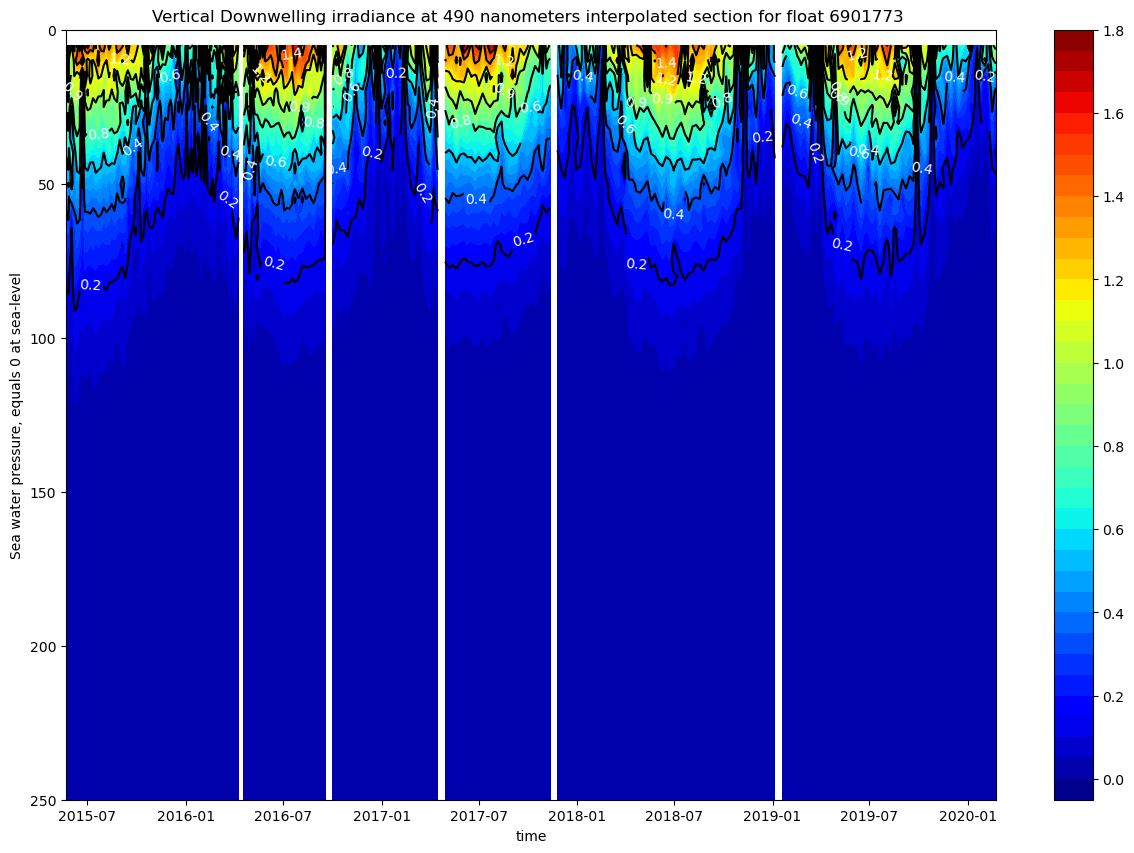

In [36]:
fig, ax = plt.subplots(figsize=(15,10))

cs=ax.contourf(juld,prei,irr490i.transpose(),40, cmap = 'jet')#, vmin = 0, vmax = 1.8)

cs2=ax.contour(juld,prei,irr490i.transpose(),colors=('k'), levels=cs.levels[::4])

ax.invert_yaxis()
ax.clabel(cs2, fmt='%2.1f', colors='w', fontsize=10)
ax.set_ylim(250, 0)

ax.set_title(f"Vertical Downwelling irradiance at 490 nanometers interpolated section for float {ds.PLATFORM_NUMBER[0].astype(str).values}")
ax.set_xlabel(f"{ds.JULD.standard_name}")
ax.set_ylabel(f"{ds.PRES.long_name}")

cbar=fig.colorbar(cs,ax=ax)

The figures show a rapid attenuation of the irradiance with depth. Light is confined to the upper 50-80m, corresponding to a relatively shallow euphotic zone. There is a clear seasonal cycle.

These plots only have data up to 250m. We only represented the downwelling irradiance of 490nm and PAR, since the information of all the plots is similar.